In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
from quiescence_analysis.src.quiescence_analysis import load_tiff
from skimage.measure import label, regionprops

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### load binarized image ###

In [3]:
img_path = r'C:\Temp\quiescence\quiescence_analysis\bin_worm_example.tiff'


In [4]:
img = load_tiff(img_path)

In [5]:
idx = 100
frame = img[:,:,idx]
next_frame = img[:,:,idx+3]

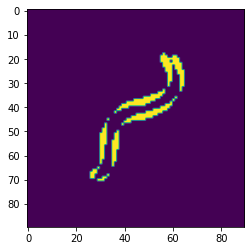

In [6]:
plt.imshow(np.abs(next_frame-frame))

In [7]:
skimageskimage.measure.label

AttributeError: No skimage attribute label

### investigate contours ###

In [39]:
frames_diff = np.abs(next_frame-frame).astype(np.uint8)

# contours, hierarchy = cv2.findContours(frames_diff, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
label_frames_diff = label(frames_diff)
objects = regionprops(label_frames_diff)

In [47]:
label_frames_diff.shape

(90, 90)

In [19]:
print("0 area is", props[0].area)


0 area is 73
0 area filled is 74


In [66]:
print("0 area is", props[0].area)
hierarchy[0][cont_idx][3]

7

In [58]:
len(contours)

9

area of 8 is: 2.0
perimeter of 8 is 5.656854152679443
manual total pixel count of 8 is 5


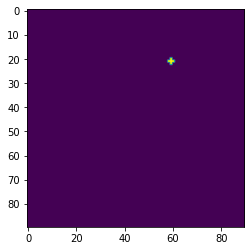

In [67]:
img_diff = np.zeros_like(frames_diff)
img_all = np.zeros_like(frames_diff)

#to draw contours, iterate over contours
for cont_idx in range(len(contours)):
    if hierarchy[0][cont_idx][3] < 0:
        continue
    cont_color = min(cont_idx*30,255)
    img_diff = np.zeros_like(frames_diff)
    cv2.drawContours(img_diff, contours,cont_idx,color=255, thickness=-2, hierarchy=hierarchy, maxLevel=1)
    cv2.drawContours(img_all, contours,cont_idx,color=cont_color, thickness=-2, hierarchy=hierarchy, maxLevel=1)
    area = cv2.contourArea(contours[cont_idx])
    perimeter = cv2.arcLength(contours[cont_idx],True)
    #johaness solution
#     mask = np.zeros_like(frames_diff)
#     x, y, w, h = cv2.boundingRect(contours[cont_idx])
#     cv2.drawContours(mask, [contours[cont_idx]], 0, (255), -1)
#     cv2.bitwise_and(img_diff,img_diff, mask= mask)
    
    print("area of",cont_idx,"is:",area)
    print("perimeter of",cont_idx,"is",perimeter)
    
#     plt.figure(dpi=300)
    plt.imshow(img_all)
    img_diff[img_diff>0] = 1
    area_total_pixels = img_diff.sum()
    print("manual total pixel count of",cont_idx,"is",area_total_pixels)


In [84]:
### need to write ###

    

In [85]:
average_worm_area = get_average_worm_area(img,22,True)
print("average_worm_area",average_worm_area)

average_worm_area 369.66857142857145


In [83]:
len(img.shape)

3

In [27]:
from math import ceil
ceil()

1

In [25]:
img.shape[2]

523

In [ ]:
### need to write ###
def filter_segments_by_size(segments,norm_size_threshold):
    #1. get all segments
    #2. measure sizes of all segments
    #3. filter segments according to size threshold that would be normalzied to worm size
    #get worm norm size using my function "get_average_worm_area"
    #this function receives:bin_img= binarized image series,fraction_frames=fraction_frames of frames to use to calculate averag area
    #4. return filtered segments
    
    return filtered_segments


In [ ]:
### need to write ###
def calculate_pixel_diff(filtered_contours():
    return pixel_diff